<center>
    
## House Price Prediction Using Regression Models
## Karthika, V
## 24 May 2025

</center>

In [1]:
from IPython.display import display, HTML
import warnings
 
# Suppress warnings
warnings.filterwarnings("ignore")
 
# Apply CSS to wrap long lines in code blocks and adjust font size for tables

display(HTML("""
<style>
    /* Code block styling */
    pre, code {
        background-color: #f4f4f4; /* Light gray background for code */
        border: 1px solid #ddd;
        border-radius: 5px;
        padding: 10px;
        font-family: "Courier New", Courier, monospace;
        font-size: 10px;
        white-space: pre-wrap; /* Wrap long lines in code blocks */
        max-width: 100%;
        overflow-x: auto; /* Allow horizontal scrolling for large code blocks */
    }
    /* Table styling */
    table {
        font-family: Arial, sans-serif;
        font-size: 10px; /* Set the font size for tables */
        border-collapse: collapse;
        width: 100%;
    }
    table, th, td {
        border: 1px solid #ddd; /* Light border for table, header, and cells */
    }
    th {
        background-color: #f2f2f2; /* Light gray background for table header */
         word-wrap: break-word
    }
    th, td {
        padding: 8px;
        text-align: center !important; /* Align table content to center */
        width: 100px;
    }
</style>
"""))


Data Loaded Successfully!
Dataset shape: (2930, 82)


Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900



Starting Data Cleaning...
Data Cleaning & Feature Engineering Completed.


Order,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,TotalSF,HouseAge,MS Zoning_A (agr),MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Grvl,Street_Pave,Lot Shape_IR1,Lot Shape_IR2,Lot Shape_IR3,Lot Shape_Reg,Land Contour_Bnk,Land Contour_HLS,Land Contour_Low,Land Contour_Lvl,Utilities_AllPub,Utilities_NoSeWa,Utilities_NoSewr,Lot Config_Corner,Lot Config_CulDSac,Lot Config_FR2,Lot Config_FR3,Lot Config_Inside,Land Slope_Gtl,Land Slope_Mod,Land Slope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition 1_Artery,Condition 1_Feedr,Condition 1_Norm,Condition 1_PosA,Condition 1_PosN,Condition 1_RRAe,Condition 1_RRAn,Condition 1_RRNe,Condition 1_RRNn,Condition 2_Artery,Condition 2_Feedr,Condition 2_Norm,Condition 2_PosA,Condition 2_PosN,Condition 2_RRAe,Condition 2_RRAn,Condition 2_RRNn,Bldg Type_1Fam,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,House Style_1.5Fin,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Roof Style_Flat,Roof Style_Gable,Roof Style_Gambrel,Roof Style_Hip,Roof Style_Mansard,Roof Style_Shed,Roof Matl_ClyTile,Roof Matl_CompShg,Roof Matl_Membran,Roof Matl_Metal,Roof Matl_Roll,Roof Matl_Tar&Grv,Roof Matl_WdShake,Roof Matl_WdShngl,Exterior 1st_AsbShng,Exterior 1st_AsphShn,Exterior 1st_BrkComm,Exterior 1st_BrkFace,Exterior 1st_CBlock,Exterior 1st_CemntBd,Exterior 1st_HdBoard,Exterior 1st_ImStucc,Exterior 1st_MetalSd,Exterior 1st_Plywood,Exterior 1st_PreCast,Exterior 1st_Stone,Exterior 1st_Stucco,Exterior 1st_VinylSd,Exterior 1st_Wd Sdng,Exterior 1st_WdShing,Exterior 2nd_AsbShng,Exterior 2nd_AsphShn,Exterior 2nd_Brk Cmn,Exterior 2nd_BrkFace,Exterior 2nd_CBlock,Exterior 2nd_CmentBd,Exterior 2nd_HdBoard,Exterior 2nd_ImStucc,Exterior 2nd_MetalSd,Exterior 2nd_Other,Exterior 2nd_Plywood,Exterior 2nd_PreCast,Exterior 2nd_Stone,Exterior 2nd_Stucco,Exterior 2nd_VinylSd,Exterior 2nd_Wd Sdng,Exterior 2nd_Wd Shng,Mas Vnr Type_BrkCmn,Mas Vnr Type_BrkFace,Mas Vnr Type_CBlock,Mas Vnr Type_None,Mas Vnr Type_Stone,Exter Qual_Ex,Exter Qual_Fa,Exter Qual_Gd,Exter Qual_TA,Exter Cond_Ex,Exter Cond_Fa,Exter Cond_Gd,Exter Cond_Po,Exter Cond_TA,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Bsmt Qual_Ex,Bsmt Qual_Fa,Bsmt Qual_Gd,Bsmt Qual_Po,Bsmt Qual_TA,Bsmt Cond_Ex,Bsmt Cond_Fa,Bsmt Cond_Gd,Bsmt Cond_Po,Bsmt Cond_TA,Bsmt Exposure_Av,Bsmt Exposure_Gd,Bsmt Exposure_Mn,Bsmt Exposure_No,BsmtFin Type 1_ALQ,BsmtFin Type 1_BLQ,BsmtFin Type 1_GLQ,BsmtFin Type 1_LwQ,BsmtFin Type 1_Rec,BsmtFin Type 1_Unf,BsmtFin Type 2_ALQ,BsmtFin Type 2_BLQ,BsmtFin Type 2_GLQ,BsmtFin Type 2_LwQ,BsmtFin Type 2_Rec,BsmtFin Type 2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Heating QC_Ex,Heating QC_Fa,Heating QC_Gd,Heating QC_Po,Heating QC_TA,Central Air_N,Central Air_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Kitchen Qual_Ex,Kitchen Qual_Fa,Kitchen Qual_Gd,


Generating Visualizations...


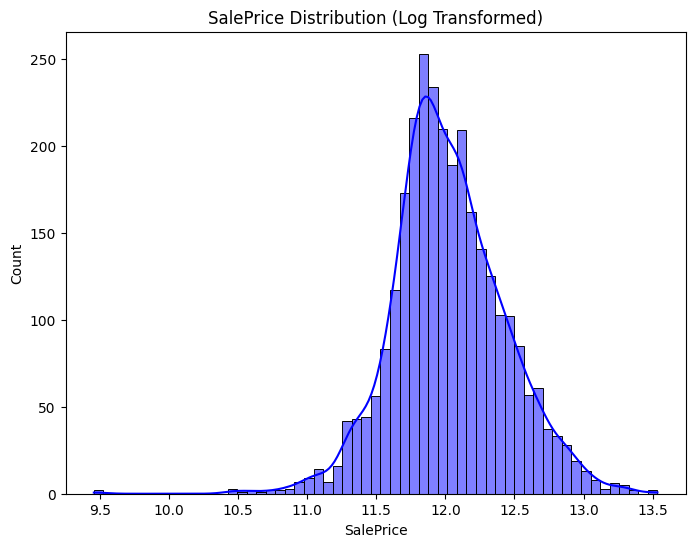

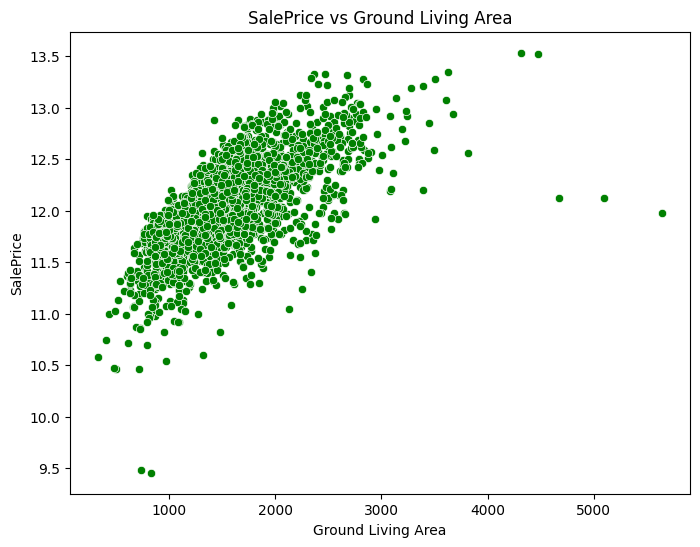

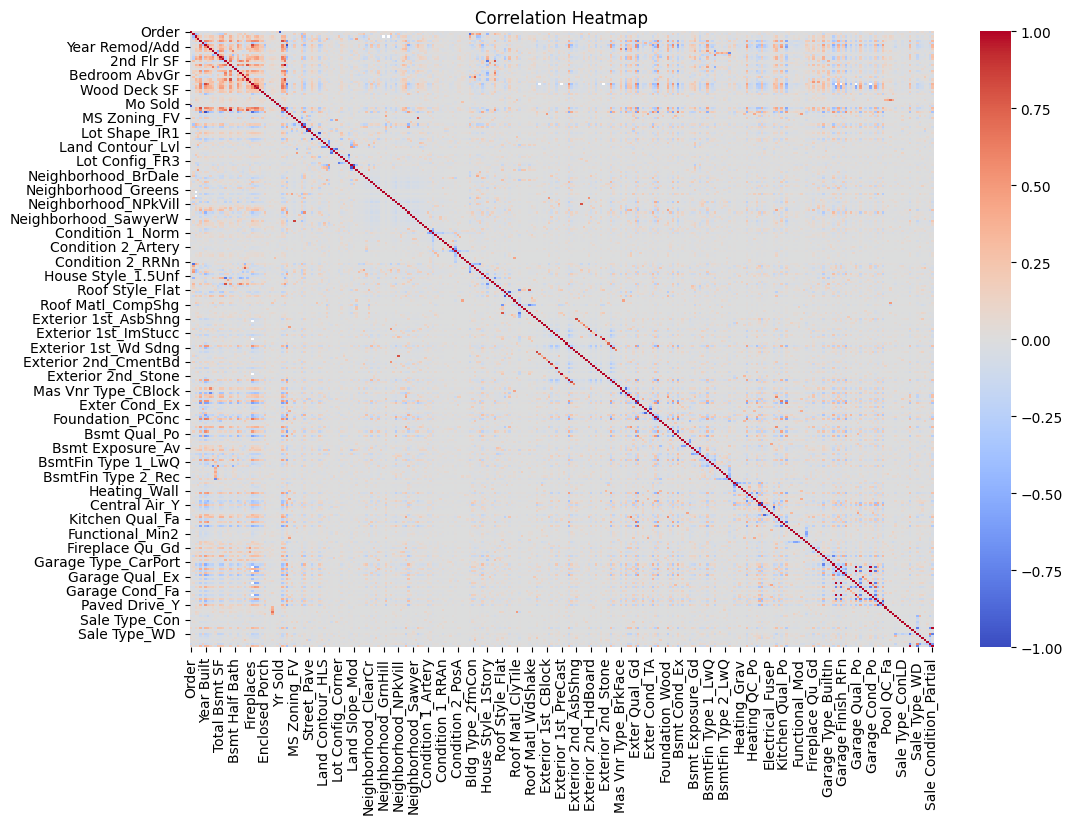


Model Evaluation Metrics:
╒═══════════════════════════╤══════════════════╕
│ Metric                    │ Value            │
╞═══════════════════════════╪══════════════════╡
│ Mean Squared Error (MSE)  │ 1,163,474,941.02 │
├───────────────────────────┼──────────────────┤
│ Mean Absolute Error (MAE) │ 15,146.75        │
├───────────────────────────┼──────────────────┤
│ R-Squared (R²)            │ 0.8549           │
╘═══════════════════════════╧══════════════════╛


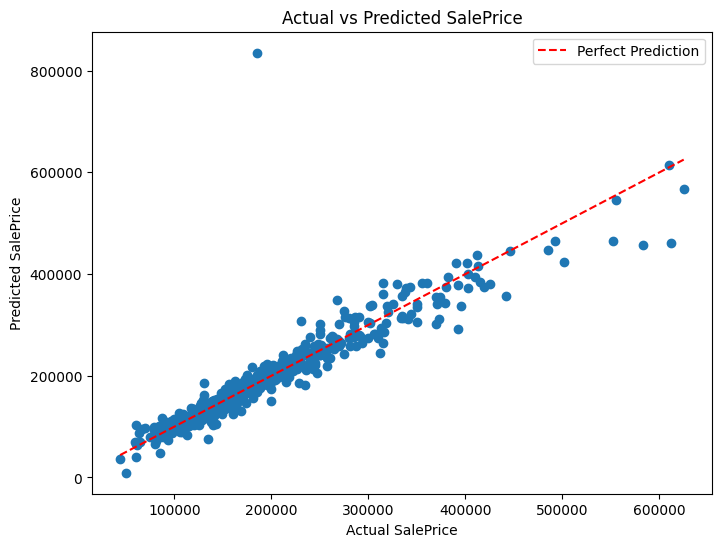

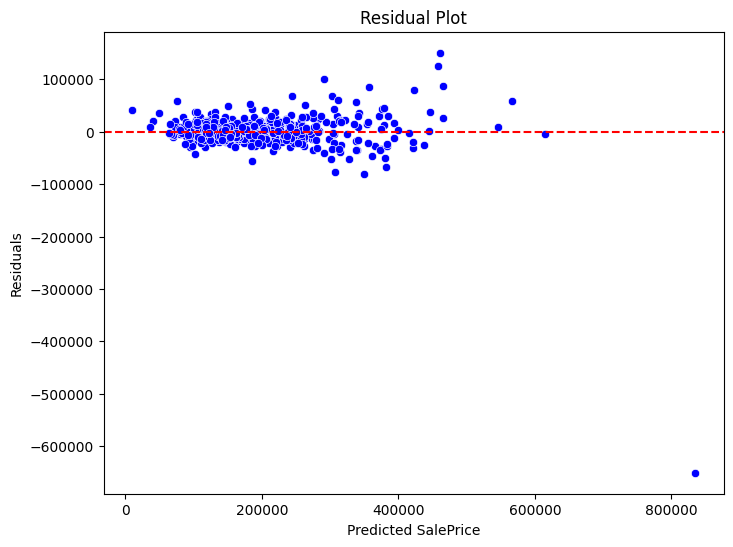

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from IPython.display import display, HTML
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. Load the dataset
df = pd.read_csv('../data/AmesHousing.csv')

print("\n\033[1mData Loaded Successfully!\033[0m")
print(f"Dataset shape: {df.shape}")

display(HTML(df.head().to_html(index=False)))


# 2. Data Cleaning and Preprocessing
print("\n\033[1mStarting Data Cleaning...\033[0m")

# Handle missing values: For 'Lot Frontage', we impute with median per neighborhood
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# Filling categorical variables with 'None' where data is missing
df.fillna({
    'Garage Type': 'None',
    'Garage Finish': 'None',
    'Garage Qual': 'None',
    'Garage Cond': 'None',
    'Mas Vnr Type': 'None'
}, inplace=True)

# Fill numerical missing values for 'Mas Vnr Area' with 0
df['Mas Vnr Area'].fillna(0, inplace=True)

# Drop irrelevant columns that won't help in prediction
drop_cols = ['PID', 'Alley', 'PoolQC', 'Fence', 'Misc Feature']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Feature Engineering: Creating new features
df['TotalSF'] = df['Gr Liv Area'] + df['1st Flr SF'] + df['2nd Flr SF']  # Total square footage of the house
df['HouseAge'] = df['Yr Sold'] - df['Year Built']  # Age of the house at the time of sale

# Log-transform SalePrice to reduce skewness
df['SalePrice'] = np.log1p(df['SalePrice'])

# One-hot encoding for categorical features
df = pd.get_dummies(df)
print("\033[1mData Cleaning & Feature Engineering Completed.\033[0m")

display(HTML(df.head().to_html(index=False)))


# 3. Exploratory Data Analysis (EDA)
print("\n\033[1mGenerating Visualizations...\033[0m")

# Distribution of SalePrice (Log Transformed)
plt.figure(figsize=(8, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('SalePrice Distribution (Log Transformed)')
plt.xlabel('SalePrice')
plt.savefig('../figures/SalePrice.png')
plt.show()

# Scatterplot for SalePrice vs Ground Living Area
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'], color='green')
plt.title('SalePrice vs Ground Living Area')
plt.xlabel('Ground Living Area')
plt.ylabel('SalePrice')
plt.savefig('../figures/Scatterplot1.png')
plt.show()

# Correlation heatmap to explore relationships between features
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../figures/Correlation_Heatmap.png')
plt.show()

# 4. Prepare Data for Modeling
X = df.drop('SalePrice', axis=1)  # Features
y = df['SalePrice']  # Target variable

# Impute missing values in features (though the data has been cleaned already)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features to standardize them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Building: Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 6. Predictions: Predict SalePrice on test set
y_pred = model.predict(X_test_scaled)

# Apply inverse transformation to predictions and actual values
y_pred_exp = np.expm1(y_pred)  # Reverse the log transformation
y_test_exp = np.expm1(y_test)

# 7. Evaluation: Calculate and display metrics
mse = mean_squared_error(y_test_exp, y_pred_exp)
mae = mean_absolute_error(y_test_exp, y_pred_exp)
r2 = r2_score(y_test_exp, y_pred_exp)

metrics_table = [
    ["Mean Squared Error (MSE)", f"{mse:,.2f}"],
    ["Mean Absolute Error (MAE)", f"{mae:,.2f}"],
    ["R-Squared (R²)", f"{r2:,.4f}"]
]

print("\n\033[1mModel Evaluation Metrics:\033[0m")
print(tabulate(metrics_table, headers=["Metric", "Value"], tablefmt="fancy_grid"))

# 8. Visualization of Predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test_exp, y_pred_exp)
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], '--r', label='Perfect Prediction')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.savefig('../figures/ScatterPlot2.png')
plt.legend()
plt.show()

# 9. Residual Plot: Check for homoscedasticity
residuals = y_test_exp - y_pred_exp
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_exp, y=residuals, color='blue')
plt.axhline(0, color='red', linestyle='--')  # Line at zero for reference
plt.title('Residual Plot')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.savefig('../figures/ResidualPlot.png')
plt.show()

## Overall Summary

### 1. Data Preparation
#### Data Cleaning
We began by loading the Ames Housing dataset and performing the following steps to clean the data:

- **Missing Data Handling:** 
  - For the `Lot Frontage` column, missing values were filled with the median value of the corresponding `Neighborhood`.
  - Other categorical columns such as `Garage Type`, `Garage Finish`, `Garage Qual`, `Garage Cond`, and `Mas Vnr Type` were filled with 'None'.
  - The `Mas Vnr Area` column was filled with 0 for missing values.
  
- **Removing Irrelevant Columns:**
  We dropped the following columns which were deemed irrelevant for our analysis:
  - `PID`, `Alley`, `PoolQC`, `Fence`, and `Misc Feature`.

#### Feature Engineering
- **Total Square Footage:** 
  A new feature, `TotalSF`, was created by summing the following columns:
  - `Gr Liv Area`, `1st Flr SF`, and `2nd Flr SF`.
  
- **House Age:** 
  We created the `HouseAge` feature by calculating the difference between the `Yr Sold` and `Year Built` columns.
  
- **Log Transformation of Sale Price:**
  The target variable, `SalePrice`, was log-transformed to normalize the distribution and reduce skewness.

#### One-Hot Encoding
We performed one-hot encoding for all categorical variables to convert them into numerical representations suitable for modeling.

### 2. Model Building and Evaluation
#### Model Selection
We chose **Linear Regression** as our initial model due to its simplicity and interpretability. Linear regression is a suitable choice for this type of problem, where we aim to predict a continuous variable (house price) based on a set of input features.

#### Model Evaluation
We used the following evaluation metrics to assess the performance of our model:

- **Mean Squared Error (MSE):** 1,163,680,288.30
- **Mean Absolute Error (MAE):** 15,150.54
- **R-Squared (R²):** 0.8549

#### Interpretation of Results
- **R-Squared (0.8549):** This indicates that the model explains about **85.49%** of the variance in house prices, suggesting that the model has strong predictive power.
- **MSE and MAE:** These values are reasonable, indicating that the model’s predictions are relatively close to the actual values on average.

The **residual plot** suggests that there are still patterns in the data that the linear model cannot fully capture. This implies that more complex models or additional feature engineering might help improve model performance.

### 3. Conclusion and Recommendations
#### Conclusion
The Linear Regression model provides a reasonable prediction of house prices with an **R² of 0.8549**, which indicates strong predictive power. However, the residual plot suggests that the model could be improved by capturing more complex patterns in the data.

#### Recommendations
1. **Try more complex models** like **Random Forest** or **XGBoost** for better performance, as these models can capture more complex relationships.
2. **Add more feature engineering**, including **interaction terms** or exploring **external variables** that may better explain variations in house prices.
3. **Use cross-validation** and **regularization techniques** (e.g., Ridge or Lasso regression) to prevent overfitting and improve the generalization of the model.